In [1]:
library(slendr)
init_env()

library(dplyr)   # manipulating tabular data
library(ggplot2) # data visualization
library(purrr)   # convenient looping


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# "Outgroup" $f_3$

Whenever we want to evaluate the behavior of some statistic of interest under a range of demographic scenarios and across different model parameters, it's always useful to first establish a skeleton structure with concrete values of model parameters, before we wrap it in a dedicated function.

Let's do this here too.

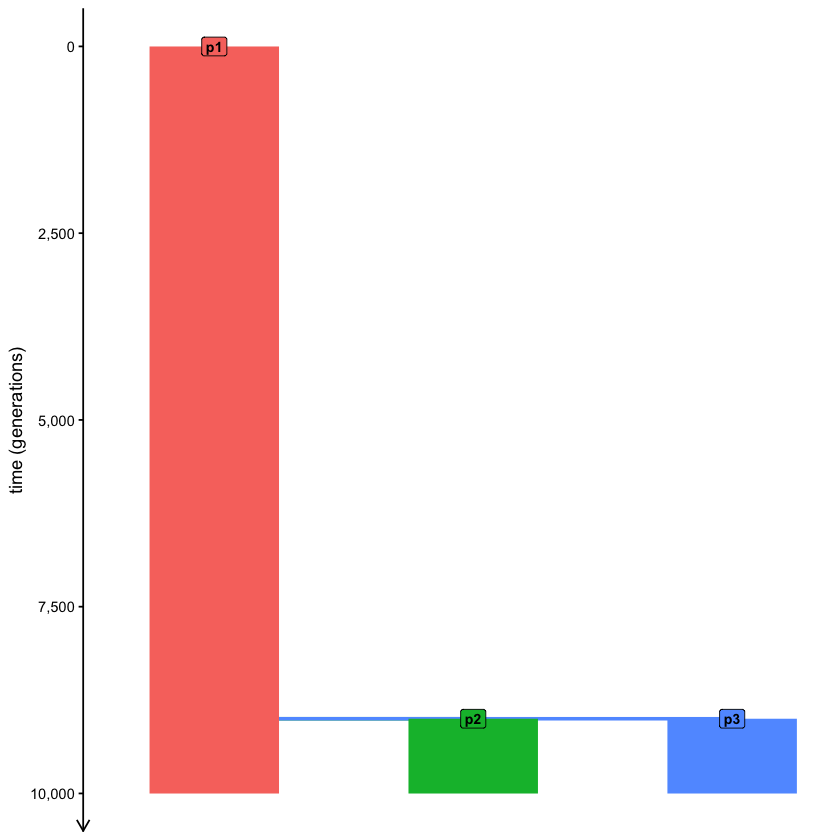

In [8]:
tsplit <- 9000

p1 <- population("p1", N = 1000, time = 1)
p2 <- population("p2", N = 1000, time = tsplit, parent = p1)
p3 <- population("p3", N = 1000, time = tsplit, parent = p1)

model <- compile_model(list(p1, p2, p3), generation_time = 1, simulation_length = 10000)

plot_model(model, order = c("p1", "p2", "p3"), proportions = TRUE)

In [16]:
compute_outgroup_f3 <- function(tsplit) {
    p1 <- population("p1", N = 1000, time = 1)
    p2 <- population("p2", N = 1000, time = tsplit, parent = p1)
    p3 <- population("p3", N = 1000, time = tsplit, parent = p1)
    
    model <- compile_model(list(p1, p2, p3), generation_time = 1, simulation_length = 10000)

    ts <- msprime(model, sequence_length = 20000000, recombination_rate = 1e-8) %>% ts_mutate(1e-8)
    samples <- ts_names(ts, split = "pop")
    
    ts_f3(ts, A = samples["p1"], B = samples["p2"], C = samples["p3"]) %>% mutate(tsplit = tsplit)
}

In [17]:
compute_outgroup_f3(1000)

A,B,C,f3,tsplit
<chr>,<chr>,<chr>,<dbl>,<dbl>
p1,p2,p3,8.700285e-05,1000


In [18]:
compute_outgroup_f3(2000)

A,B,C,f3,tsplit
<chr>,<chr>,<chr>,<dbl>,<dbl>
p1,p2,p3,7.978066e-05,2000


In [19]:
compute_outgroup_f3(5000)

A,B,C,f3,tsplit
<chr>,<chr>,<chr>,<dbl>,<dbl>
p1,p2,p3,5.021369e-05,5000


In [30]:
f3_outgroup <- map_dfr(seq(500, 10000, by = 1000), compute_outgroup_f3)

In [31]:
head(f3_outgroup)

A,B,C,f3,tsplit
<chr>,<chr>,<chr>,<dbl>,<dbl>
p1,p2,p3,8.740232e-05,500
p1,p2,p3,8.295544e-05,1500
p1,p2,p3,7.331226e-05,2500
p1,p2,p3,6.799008e-05,3500
p1,p2,p3,5.273266e-05,4500
p1,p2,p3,4.227020e-05,5500


`geom_smooth()` using formula = 'y ~ x'


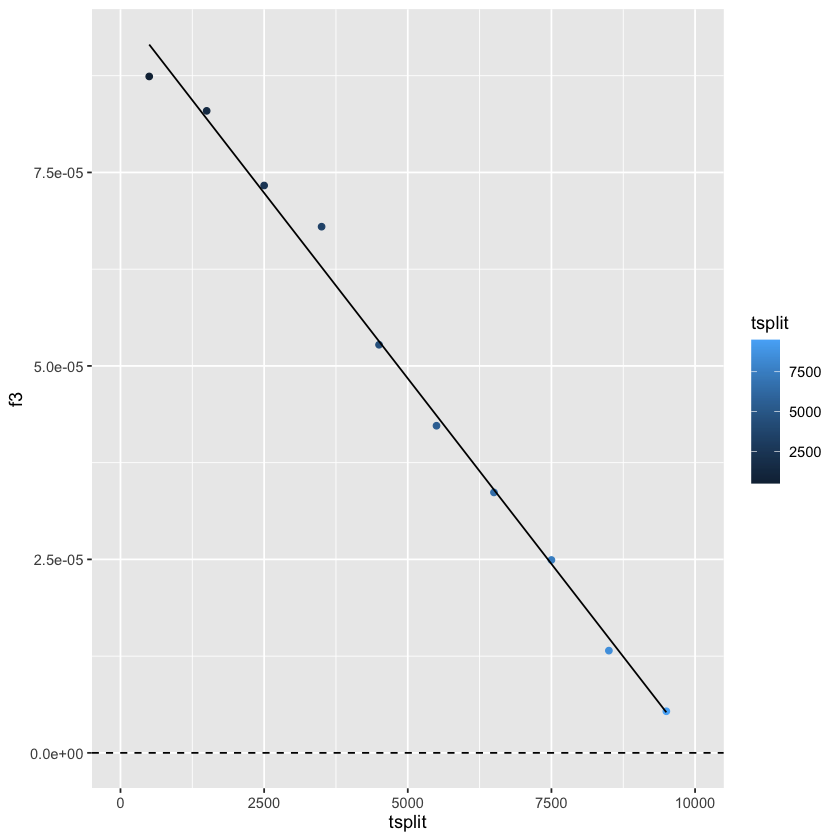

In [39]:
ggplot(f3_outgroup, aes(tsplit, f3, color = tsplit)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.5) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_cartesian(xlim = c(0, 10000))

# "Admixture" $f_3$

Now let's explore the application of the $f_3$ statistic in its other common use, which is an admixture test. 
To do this, you will need to expand our baseline population model a little bit.

The population `p1` is still the outgroup, but the `p2` and `p3` population now merge at a time `tmix` to form a population `px`. Note that due to the way in which _slendr_ currently implements population merges, you will first need to program the split of `px` from  `p2` at time `tmix - 1`, followed immediately at time `tmix` by admixture from `p2` at some define total proportion `rate`. To approximate the idea of a population merge as closely as possible within the constraints of the _slendr_ interface, program this admixture to end after a single generation (i.e., ending at time `tmix + 1`).

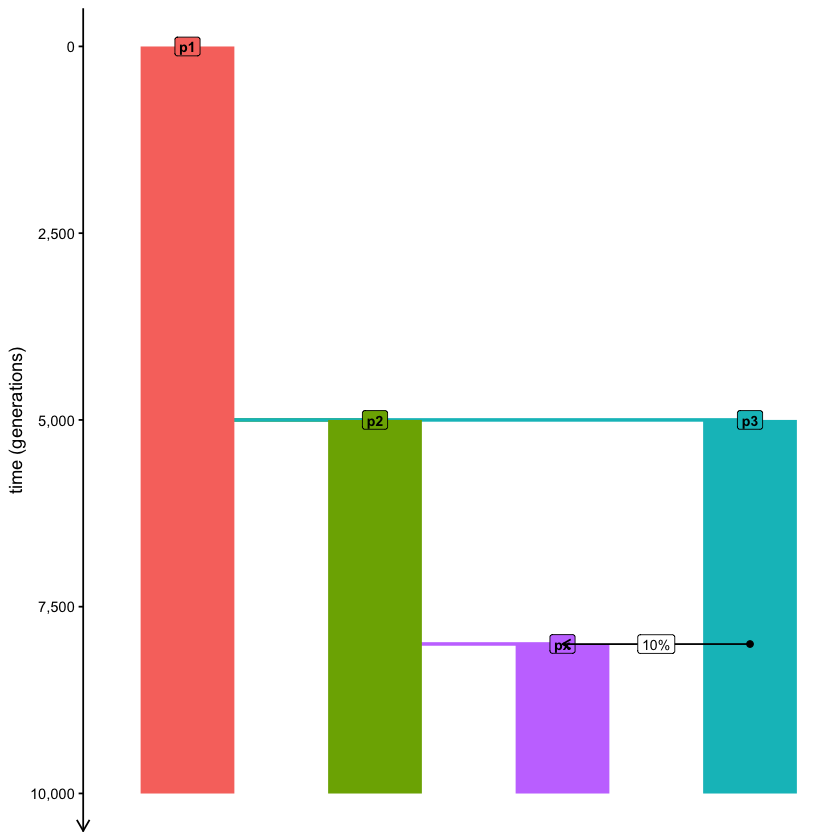

In [3]:
tmix <- 8000
prop <- 0.1
Ne <- 5000

p1 <- population("p1", N = 5000, time = 1)
p2 <- population("p2", N = 5000, time = 5000, parent = p1)
p3 <- population("p3", N = 5000, time = 5000, parent = p1)
px <- population("px", N = Ne, time = tmix - 1, parent = p2)
gf <- gene_flow(from = p3, to = px, start = tmix, end = tmix + 1, proportion = prop)

model <- compile_model(list(p1, p2, p3, px), gene_flow = gf, generation_time = 1, simulation_length = 10000)

plot_model(model, order = c("p1", "p2", "px", "p3"), proportions = TRUE)

In [44]:
compute_admix_f3 <- function(tmix, prop, Ne) {    
  p1 <- population("p1", N = 5000, time = 1)
  p2 <- population("p2", N = 5000, time = 5000, parent = p1)
  p3 <- population("p3", N = 5000, time = 5000, parent = p1)
  px <- population("px", N = Ne, time = tmix - 1, parent = p2)
  gf <- gene_flow(from = p3, to = px, start = tmix, end = tmix + 1, proportion = prop)
  
  model <- compile_model(list(p1, p2, p3, px), gene_flow = gf, generation_time = 1, simulation_length = 10000)

  ts <- msprime(model, sequence_length = 20000000, recombination_rate = 1e-8) %>% ts_mutate(1e-8)

  samples <- ts_names(ts, split = "pop")

  ts_f3(ts, A = samples["px"], B = samples["p1"], C = samples["p2"]) %>%
    mutate(tmix = tmix, prop = prop, Ne = Ne)
}

In [21]:
compute_admix_f3(8000, 0.1, 5000)

A,B,C,f3,tmix,prop
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
px,p1,p2,1.856511e-05,8000,0.1


In [22]:
compute_admix_f3(9000, 0.1, 5000)

A,B,C,f3,tmix,prop
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
px,p1,p2,8.334248e-06,9000,0.1


In [23]:
compute_admix_f3(10000, 0.1, 5000)

A,B,C,f3,tmix,prop
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
px,p1,p2,-4.067515e-06,10000,0.1


In [29]:
f3_tmix1 <- map_dfr(seq(9000, 10000, by = 50), compute_admix_f3, prop = 0.1, Ne = 5000)

`geom_smooth()` using formula = 'y ~ x'


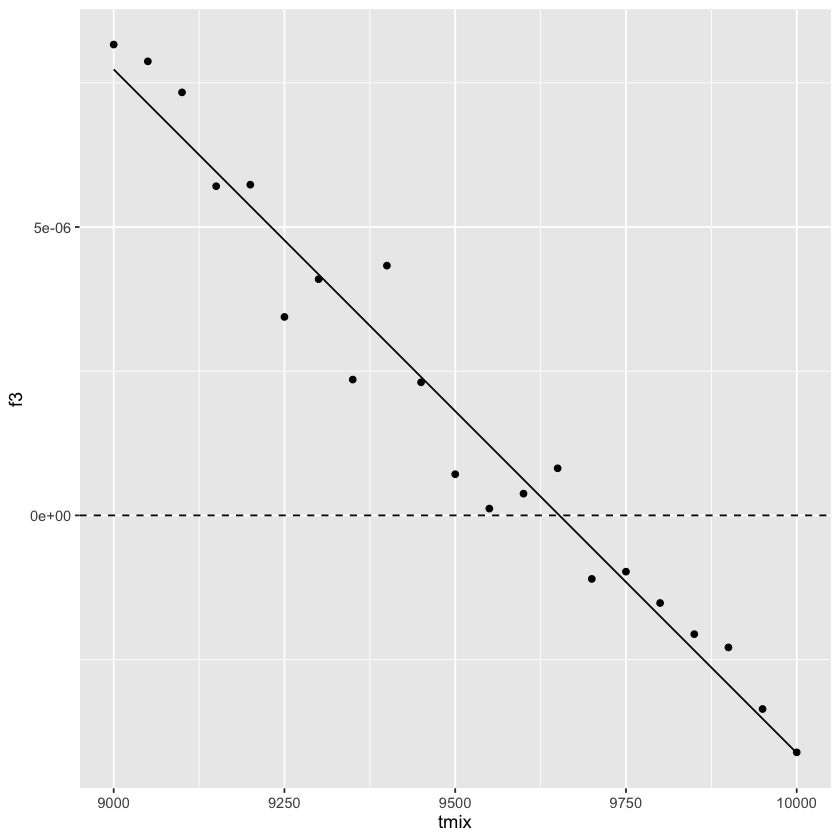

In [30]:
ggplot(f3_tmix1, aes(tmix, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.5) +
  coord_cartesian(xlim = c(9000, 10000))

Clearly, the trend presented by the $f_3$ values suggests that the statistic loses power to detect admixture sometime around 500 generations before the age of our `px` samples.

Under which conditions would the $f_3$ statistic gain more power?

#### Exercise

Fix the `tadmix` parameter to 9500 (a value at which our previous simulation suggests $f_3$ losing power) and evaluate a range of admixture proportions `prop` up to 50% gene flow. Does $f_3$ pick up the admixture signal for any admixture proportion?

In [39]:
f3_prop <- map_dfr(seq(0, 0.5, by = 0.05), compute_admix_f3, tmix = 9500, Ne = 5000)

`geom_smooth()` using formula = 'y ~ x'


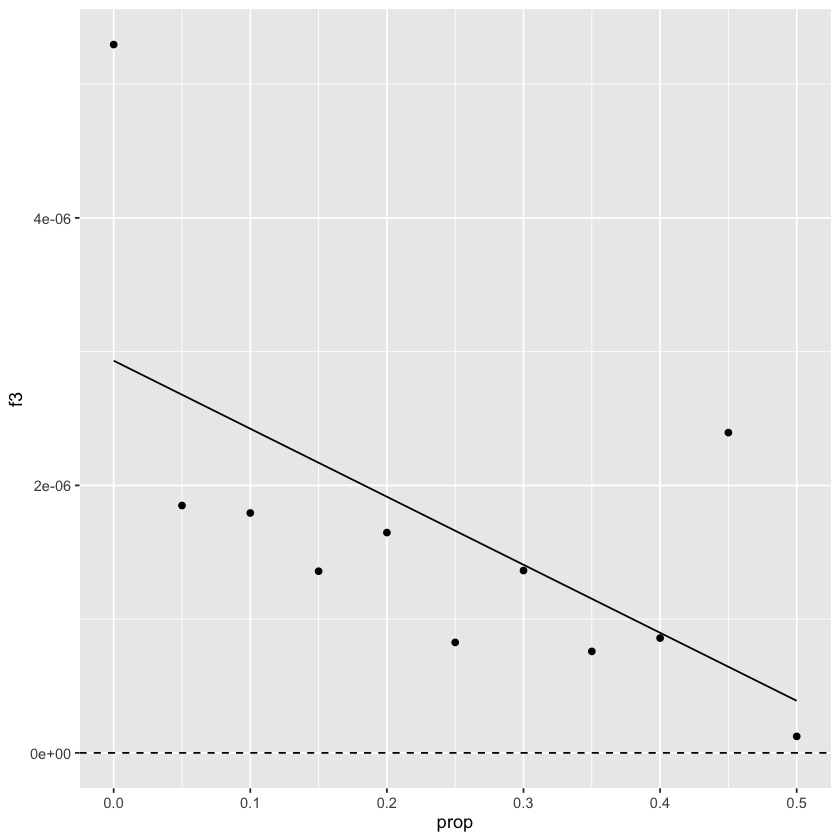

In [69]:
ggplot(f3_prop, aes(prop, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.5) +
  coord_cartesian(xlim = c(0, 0.5))

Increase `Ne` baseline:

In [77]:
f3_prop <- map_dfr(seq(0, 0.5, by = 0.05), compute_admix_f3, tmix = 9500, Ne = 20000)

`geom_smooth()` using formula = 'y ~ x'


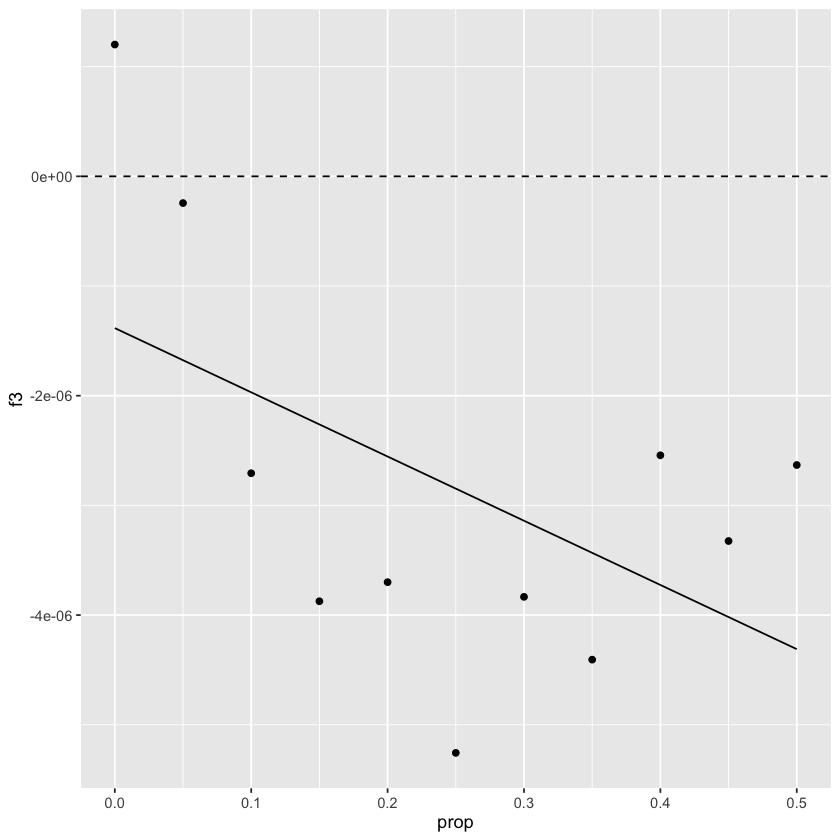

In [78]:
ggplot(f3_prop, aes(prop, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.5) +
  coord_cartesian(xlim = c(0, 0.5))

#### Exercise

It looks like the answer is "no". How about when you do the same but this time fixing `prop = 0.1` and keeping `tmix = 9500` (i.e., values for which our original $f_3$ simulation didn't pick up evidence of admixture), but this time evaluating a range of `Ne` values across `seq(from = 5000, to = 25000, by = 2500)`? Increasing values of `Ne` minimize the effect of genetic drift after admixture—do you see this also increasing the statistical power of $f_3$?

In [73]:
f3_Ne <- map_dfr(seq(from = 1000, to = 30000, by = 1000), compute_admix_f3, tmix = 9500, prop = 0.2)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


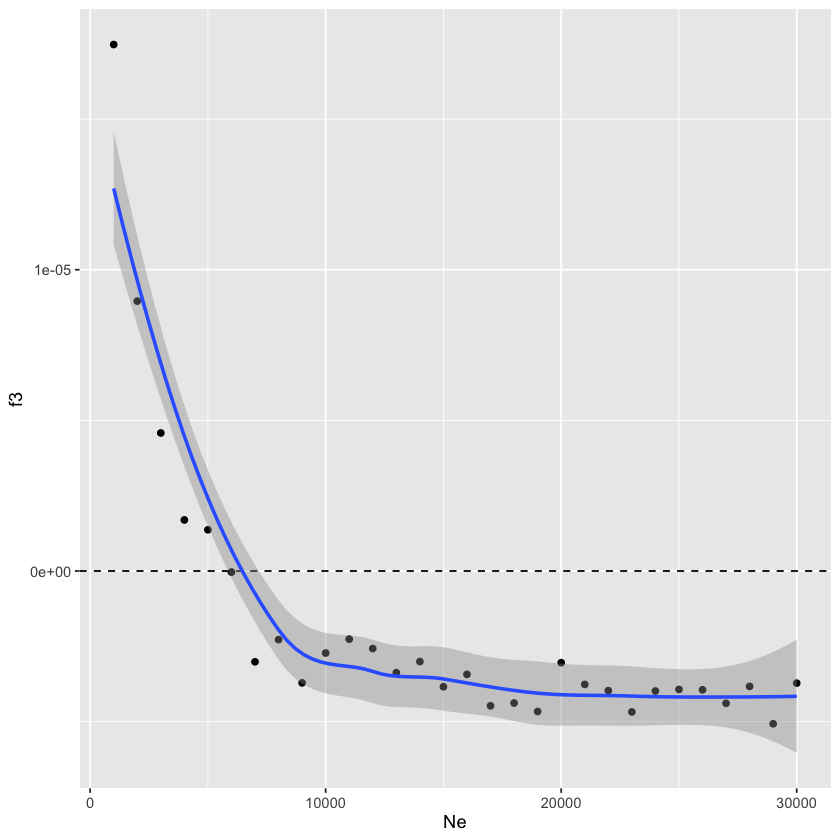

In [75]:
ggplot(f3_Ne, aes(Ne, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth()

It looks like the amount of drift (represented by the `Ne` parameter) really is what determines whether or not can $f_3$ detect admixture for a given model (represented by a fixed `tmix` time and `prop` admixture proportion). In fact, once we reach a certain size of the admixed population, the $f_3$ value reaches a stable level below zero.

In [73]:
f3_Ne <- map_dfr(seq(from = 1000, to = 30000, by = 1000), compute_admix_f3, tmix = 9500, prop = 0.2)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


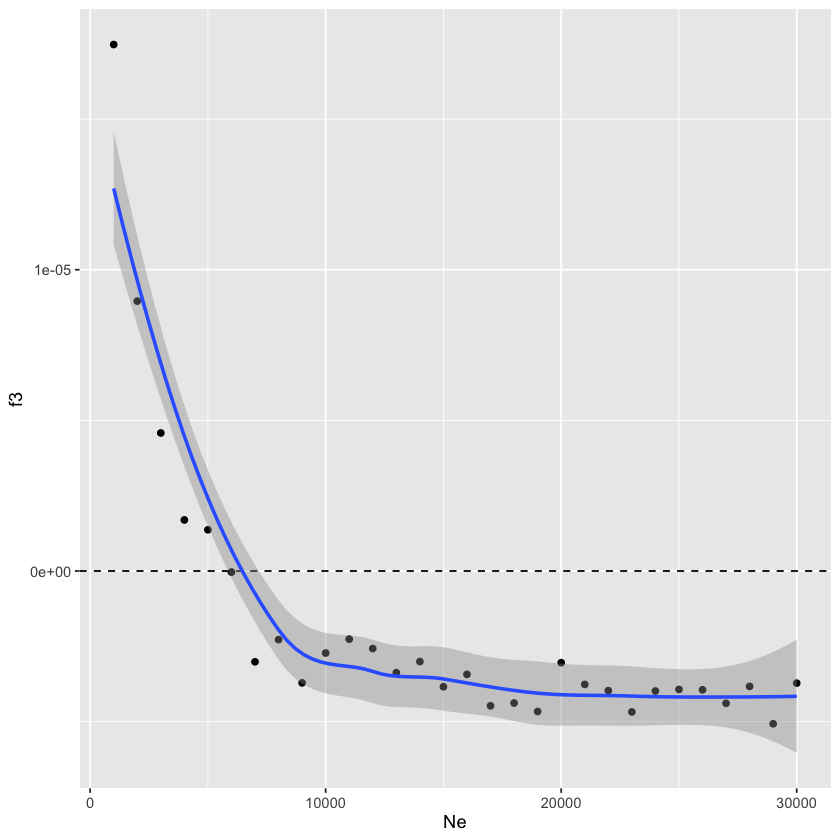

In [75]:
ggplot(f3_Ne, aes(Ne, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth()

#### Exercise

`geom_smooth()` using formula = 'y ~ x'


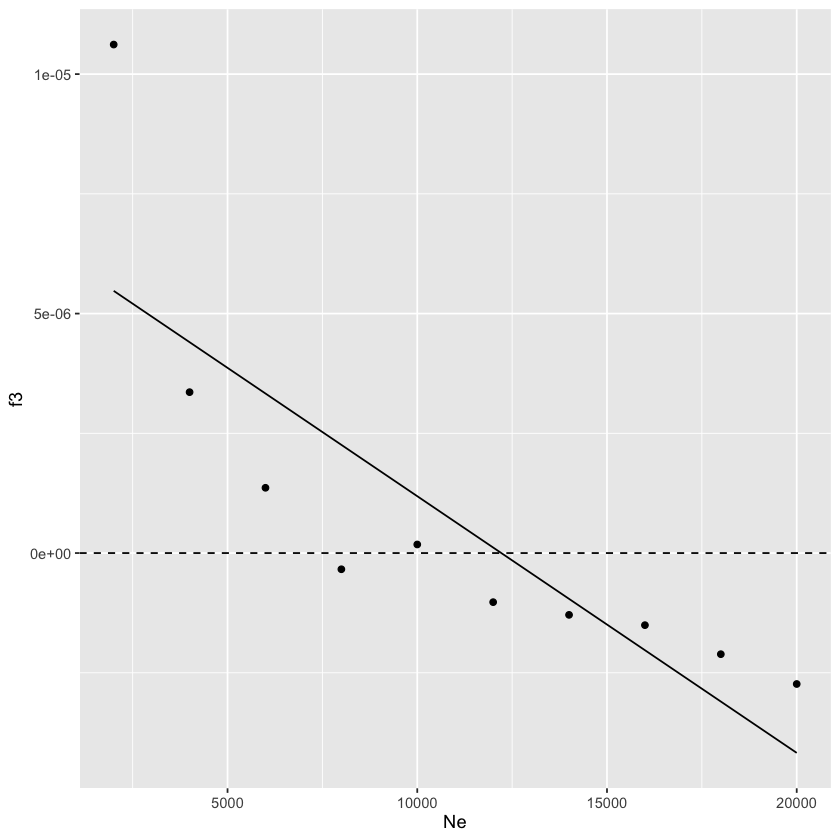

In [67]:
ggplot(f3_Ne, aes(Ne, f3)) +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.5)

# Exercises

- amount of SNPs and amount of sequence vs Zscore & CI